# Notebook with data visualization to understand skew in the protected attributes and label on german credit data

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from falsb4mpa.dataset.load_data import load_data

### Titanic data (pre-prep)

In [2]:
data = pd.read_csv("../../../data/processed/german/german_mpa_bin_wout_agg.csv", index_col=0)

In [3]:
data.head()

,Sex,Age,Credit amount,Duration,Job_0,Job_1,Job_2,Job_3,Housing_free,Housing_own,...,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk
0,0,0,0.050567,0.029412,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,1
1,1,0,0.313690,0.647059,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,0,1,0.101574,0.117647,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
3,0,1,0.419941,0.558824,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
4,0,1,0.254209,0.294118,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0


In [4]:
len(data.index)

1000

In [5]:
data.columns

Index(['Sex', 'Age', 'Credit amount', 'Duration', 'Job_0', 'Job_1', 'Job_2',
       'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Saving accounts_little', 'Saving accounts_moderate',
       'Saving accounts_none', 'Saving accounts_quite rich',
       'Saving accounts_rich', 'Checking account_little',
       'Checking account_moderate', 'Checking account_none',
       'Checking account_rich', 'Purpose_business', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others', 'Risk'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sex                          1000 non-null   int64  
 1   Age                          1000 non-null   int64  
 2   Credit amount                1000 non-null   float64
 3   Duration                     1000 non-null   float64
 4   Job_0                        1000 non-null   int64  
 5   Job_1                        1000 non-null   int64  
 6   Job_2                        1000 non-null   int64  
 7   Job_3                        1000 non-null   int64  
 8   Housing_free                 1000 non-null   int64  
 9   Housing_own                  1000 non-null   int64  
 10  Housing_rent                 1000 non-null   int64  
 11  Saving accounts_little       1000 non-null   int64  
 12  Saving accounts_moderate     1000 non-null   int64  
 13  Saving accounts_none    

In [7]:
data.head()

,Sex,Age,Credit amount,Duration,Job_0,Job_1,Job_2,Job_3,Housing_free,Housing_own,...,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk
0,0,0,0.050567,0.029412,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,1
1,1,0,0.313690,0.647059,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,0,1,0.101574,0.117647,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
3,0,1,0.419941,0.558824,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,1
4,0,1,0.254209,0.294118,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0


### Viz

In [8]:
data['Risk'].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

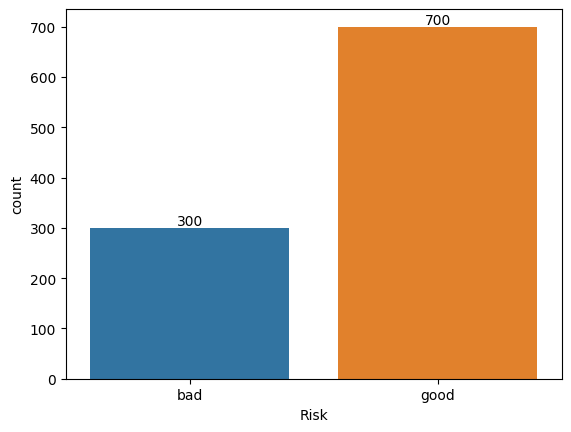

In [ ]:
cols = ['Risk', 'count']
risk = ['bad', 'good']
res_df = pd.DataFrame(columns=cols, dtype='object')

train_counts = data['Risk'].value_counts()
train_df = pd.DataFrame(
    data=[
        [risk[0], train_counts[0]],
        [risk[1], train_counts[1]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='Risk',y='count',data=res_df,hue='Risk', dodge=False)
# plt.legend(bbox_to_anchor=(1.25,1.02), loc="upper right")
plt.legend([], frameon=False)
plt.show()

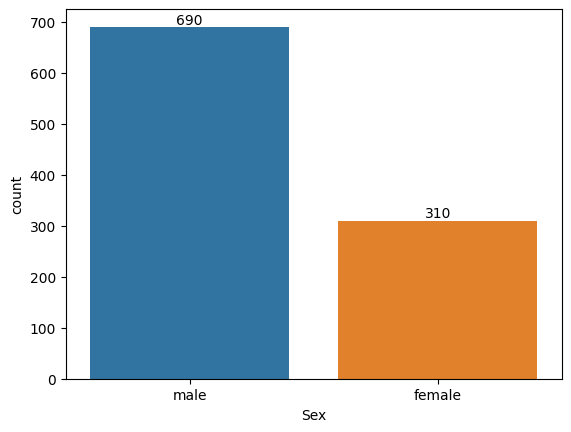

In [10]:
cols = ['Sex', 'count']
sex = ['male', 'female']
res_df = pd.DataFrame(columns=cols, dtype='object')

train_counts = data['Sex'].value_counts()
train_df = pd.DataFrame(
    data=[
        [sex[0], train_counts[0]],
        [sex[1], train_counts[1]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='Sex',y='count',data=res_df,hue='Sex', dodge=False)
# plt.legend(loc="upper right")
plt.legend([], frameon=False)
plt.show()


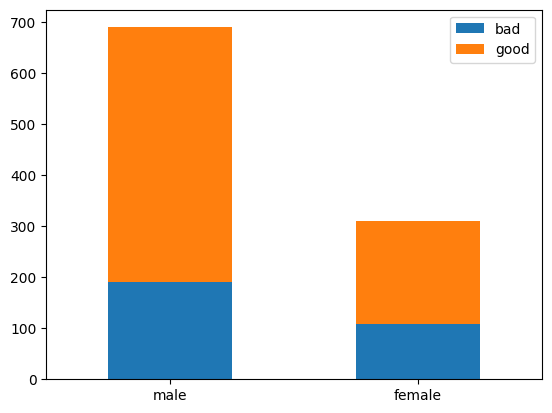

In [11]:
good = data[data['Risk'] == 1]
man_good = len(good[good['Sex'] == 0].index)
woman_good = len(good[good['Sex'] == 1].index)

bad = data[data['Risk'] == 0]
man_bad = len(bad[bad['Sex'] == 0].index)
woman_bad = len(bad[bad['Sex'] == 1].index)


res_df = pd.DataFrame(
    {
        'bad': [man_bad, woman_bad],
        'good': [man_good, woman_good],
    },
    index=['male', 'female']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

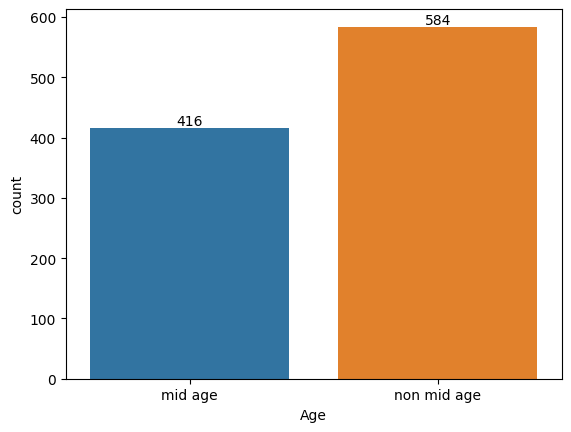

In [12]:
cols = ['Age', 'count']
age = ['mid age', 'non mid age']
res_df = pd.DataFrame(columns=cols, dtype='object')

train_counts = data['Age'].value_counts()
train_df = pd.DataFrame(
    data=[
        [age[0], train_counts[0]],
        [age[1], train_counts[1]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='Age',y='count',data=res_df,hue='Age', dodge=False)
# plt.legend(loc="upper right")
plt.legend([], frameon=False)
plt.show()


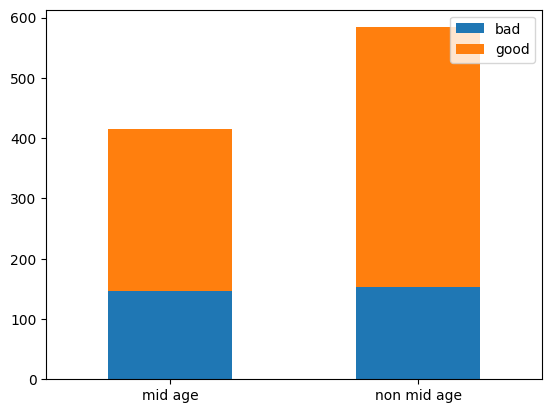

In [13]:
good = data[data['Risk'] == 1]
non_mid_age_good = len(good[good['Age'] == 0].index)
mid_age_good = len(good[good['Age'] == 1].index)

bad = data[data['Risk'] == 0]
non_mid_age_bad = len(bad[bad['Age'] == 0].index)
mid_age_bad = len(bad[bad['Age'] == 1].index)


res_df = pd.DataFrame(
    {
        'bad': [non_mid_age_bad, mid_age_bad],
        'good': [non_mid_age_good, mid_age_good],
    },
    index=['mid age', 'non mid age']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

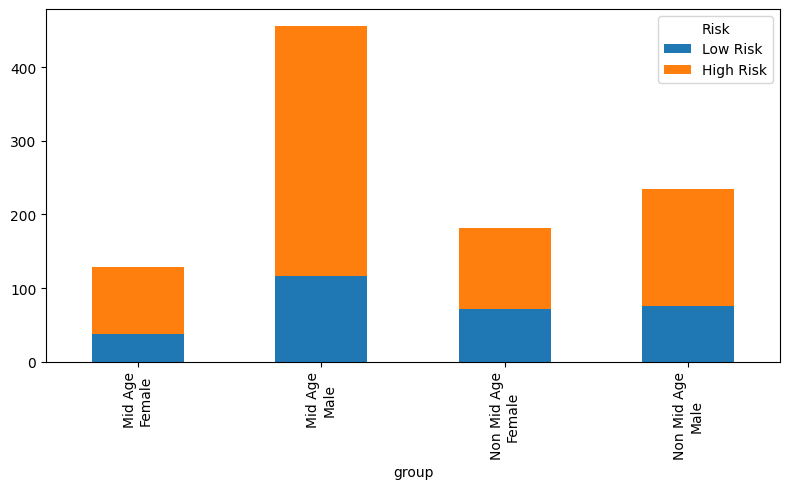

In [18]:
data['group'] = (
    data['Age'].map({
        0: 'Non Mid Age',
        1: 'Mid Age'
    }) + '\n' +
    data['Sex'].map({
        0: 'Male',
        1: 'Female'
    })
)

# Count risk values within each subgroup
risk_dist = (
    data.groupby(['group', 'Risk'])
      .size()
      .unstack(fill_value=0)
)

# Convert counts to proportions (optional)
risk_dist = risk_dist.reindex(columns=[0, 1], fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

risk_dist.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.legend(title='Risk', labels=['Low Risk', 'High Risk'])

plt.tight_layout()
plt.show()